<h1 style="text-align: center" class="list-group-item list-group-item-action active">Introduction</h1><a id="1"></a>

In Natural Language Processing, before feeding text into a machine learning model we need to turn it into
numbers — this is called **text representation**. In this notebook, we build a **sentiment classifier** for
app reviews (negative / neutral / positive) and compare **two text representation approaches**:

1. **TF-IDF** — a classical, sparse, count-based representation.
2. **spaCy word embeddings** — a dense representation using pretrained word vectors.

Both representations are evaluated using the exact same classifier and the exact same preprocessing pipeline,
so the comparison isolates the effect of the representation itself.

<h1 style="text-align: center;" class="list-group-item list-group-item-action active">Table of Contents</h1>
<a class="list-group-item list-group-item" href="#1">1. Introduction</a>
<a class="list-group-item list-group-item" href="#2">2. Load the Dataset</a>
<a class="list-group-item list-group-item" href="#3">3. Basic Text Preprocessing</a>
<a class="list-group-item list-group-item" href="#4">4. TF-IDF Representation</a>
<a class="list-group-item list-group-item" href="#5">5. spaCy Word Embeddings Representation</a>
<a class="list-group-item list-group-item" href="#6">6. Comparison &amp; Evaluation</a>
<a class="list-group-item list-group-item" href="#7">7. Conclusion</a>

<h1 style="text-align: center" class="list-group-item list-group-item-action active">Load the Dataset</h1><a id="2"></a>

The dataset contains app reviews labeled with sentiment: `0 = negative`, `1 = neutral`, `2 = positive`.

In [1]:
import pandas as pd
import numpy as np
import re
import spacy
import matplotlib.pyplot as plt

nlp = spacy.load('en_core_web_md')

df = pd.read_csv('all_data.csv')
df = df.dropna(subset=['review', 'sentiment']).reset_index(drop=True)
print(f"Number of reviews: {len(df)}")
df.head()

Number of reviews: 40516


,review,sentiment
0,Aditya Ingole Deaf,2
1,I love the app.! There is no issue but if u co...,1
2,"So hard to use. The web app failed, and the mo...",0
3,I hate that the app makes a sound every time s...,1
4,Useless at BSE star MF meet.voice too mych slo...,0


In [2]:
df['sentiment'].value_counts()

sentiment
2    15302
0    13466
1    11748
Name: count, dtype: int64

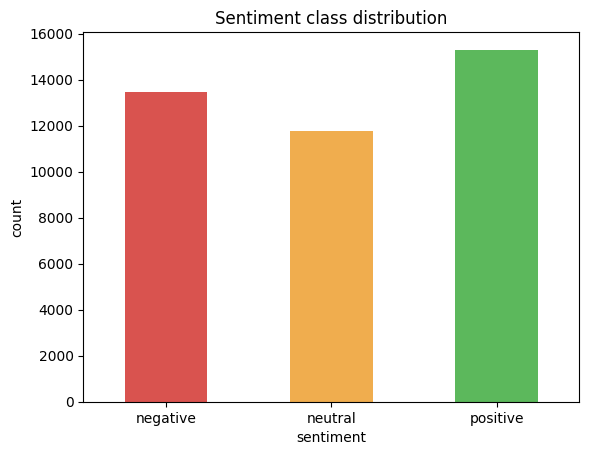

In [3]:
df['sentiment'].value_counts().sort_index().plot(
    kind='bar', color=['#d9534f', '#f0ad4e', '#5cb85c']
)
plt.xticks([0, 1, 2], ['negative', 'neutral', 'positive'], rotation=0)
plt.title('Sentiment class distribution')
plt.ylabel('count')
plt.show()

<h1 style="text-align: center" class="list-group-item list-group-item-action active">Basic Text Preprocessing</h1><a id="3"></a>

Text preprocessing is a key step before building any representation. We lowercase the text, remove URLs and
non-alphabetic characters, and collapse extra whitespace. This step is applied **once**, and both
representations below are built from the same cleaned text, so the comparison is fair.

In [4]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_review'] = df['review'].map(preprocess_text)
df = df[df['clean_review'].str.len() > 0].reset_index(drop=True)
print(f"Reviews remaining after cleaning: {len(df)}")
df[['review', 'clean_review']].head()

Reviews remaining after cleaning: 39804


,review,clean_review
0,Aditya Ingole Deaf,aditya ingole deaf
1,I love the app.! There is no issue but if u co...,i love the app there is no issue but if u coul...
2,"So hard to use. The web app failed, and the mo...",so hard to use the web app failed and the mobi...
3,I hate that the app makes a sound every time s...,i hate that the app makes a sound every time s...
4,Useless at BSE star MF meet.voice too mych slo...,useless at bse star mf meet voice too mych slo...


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'], df['sentiment'], test_size=0.2, random_state=42, stratify=df['sentiment']
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 31843, Test: 7961


<h1 style="text-align: center" class="list-group-item list-group-item-action active">TF-IDF Representation</h1><a id="4"></a>

TF-IDF (Term Frequency - Inverse Document Frequency) weighs each word by how often it appears in a review,
discounted by how common it is across all reviews. This gives more weight to words that are distinctive for
a particular review, rather than words that appear everywhere (like "the", "app").

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")

TF-IDF matrix shape: (31843, 10000)


In [7]:
# a look at some of the top-weighted words in the vocabulary
feature_names = tfidf.get_feature_names_out()
feature_names[:15]

array(['aa', 'aaa', 'aad', 'aahe', 'aam', 'aameen', 'aand', 'aandi',
       'aane', 'aap', 'aaplication', 'aapna', 'aapp', 'aaps', 'aati'],
      dtype=object)

**Advantages of TF-IDF**: simple to compute, works well even with limited data, and directly captures the
exact vocabulary of the domain (useful here since app reviews use a lot of domain-specific words like "crash",
"lag", "buffer").

**Disadvantages**: it ignores word order and word meaning — "good" and "great" are treated as completely
unrelated dimensions, even though they mean almost the same thing.

<h1 style="text-align: center" class="list-group-item list-group-item-action active">spaCy Word Embeddings Representation</h1><a id="5"></a>

Word embeddings represent each word as a dense, pretrained vector that captures some notion of meaning,
learned from a huge external corpus. Let's first check how the `en_core_web_md` model represents a couple of
words.

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

words = ['good', 'great', 'bad', 'terrible']
vectors = np.array([nlp(w).vector for w in words])
pd.DataFrame(cosine_similarity(vectors, vectors), index=words, columns=words).round(2)

,good,great,bad,terrible
good,1.00,0.52,1.00,0.74
great,0.52,1.00,0.52,0.38
bad,1.00,0.52,1.00,0.74
terrible,0.74,0.38,0.74,1.00


Unlike with TF-IDF, `good` and `great` are close to each other in this space, since the model learned that they're used in similar contexts.

In [9]:
def get_avg_vectors(texts, nlp_model):
    return np.array([doc.vector for doc in nlp_model.pipe(texts, batch_size=256)])

X_train_emb = get_avg_vectors(X_train, nlp)
X_test_emb = get_avg_vectors(X_test, nlp)
print(f"spaCy embeddings shape: {X_train_emb.shape}")

spaCy embeddings shape: (31843, 300)


**Advantages of spaCy word embeddings**: captures semantic similarity between words, works well when the
vocabulary in the test data overlaps with general English usage, and gives a fixed 300-dimensional
representation regardless of review length.

**Disadvantages**: pretrained on general text, so slang, typos, and code-mixed/non-English text (all common
in this dataset) are poorly represented — unknown words just get a zero vector.

<h1 style="text-align: center" class="list-group-item list-group-item-action active">Comparison &amp; Evaluation</h1><a id="6"></a>

We now train the **same classifier** (`LogisticRegression`) on both representations, and evaluate both on the
exact same test set, so the only variable that changes is the representation.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

clf_tfidf = LogisticRegression(max_iter=1000, random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train)

clf_emb = LogisticRegression(max_iter=1000, random_state=42)
clf_emb.fit(X_train_emb, y_train)
print("Both classifiers trained.")

Both classifiers trained.


In [11]:
pred_tfidf = clf_tfidf.predict(X_test_tfidf)
acc_tfidf = accuracy_score(y_test, pred_tfidf)
f1_tfidf = f1_score(y_test, pred_tfidf, average='macro')

print(f"TF-IDF -> accuracy: {acc_tfidf:.4f}, macro F1: {f1_tfidf:.4f}\n")
print(classification_report(y_test, pred_tfidf))

TF-IDF -> accuracy: 0.6524, macro F1: 0.6330

              precision    recall  f1-score   support

           0       0.69      0.70      0.69      2657
           1       0.53      0.42      0.47      2302
           2       0.69      0.79      0.74      3002

    accuracy                           0.65      7961
   macro avg       0.64      0.64      0.63      7961
weighted avg       0.64      0.65      0.64      7961



In [12]:
pred_emb = clf_emb.predict(X_test_emb)
acc_emb = accuracy_score(y_test, pred_emb)
f1_emb = f1_score(y_test, pred_emb, average='macro')

print(f"spaCy embeddings -> accuracy: {acc_emb:.4f}, macro F1: {f1_emb:.4f}\n")
print(classification_report(y_test, pred_emb))

spaCy embeddings -> accuracy: 0.5421, macro F1: 0.5025

              precision    recall  f1-score   support

           0       0.54      0.62      0.58      2657
           1       0.43      0.22      0.29      2302
           2       0.58      0.72      0.64      3002

    accuracy                           0.54      7961
   macro avg       0.52      0.52      0.50      7961
weighted avg       0.52      0.54      0.52      7961



In [13]:
comparison = pd.DataFrame({
    'Representation': ['TF-IDF', 'spaCy embeddings'],
    'Accuracy': [acc_tfidf, acc_emb],
    'Macro F1': [f1_tfidf, f1_emb]
})
comparison

,Representation,Accuracy,Macro F1
0,TF-IDF,0.652431,0.632984
1,spaCy embeddings,0.542143,0.502496


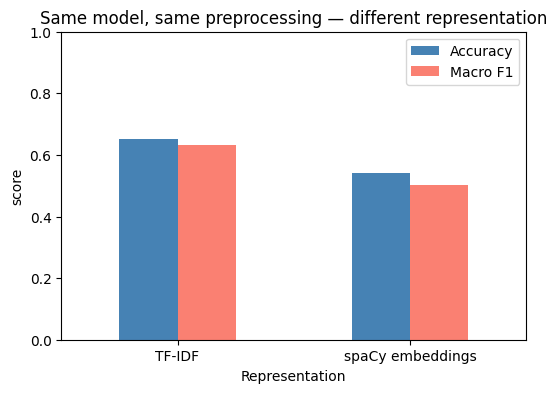

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
comparison.plot(x='Representation', y=['Accuracy', 'Macro F1'], kind='bar', ax=ax,
                 color=['steelblue', 'salmon'])
plt.ylim(0, 1)
plt.title('Same model, same preprocessing — different representation')
plt.ylabel('score')
plt.xticks(rotation=0)
plt.show()

### Try it on new reviews

In [15]:
def predict_sentiment(text):
    clean = preprocess_text(text)
    mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
    tfidf_pred = mapping[clf_tfidf.predict(tfidf.transform([clean]))[0]]
    emb_pred = mapping[clf_emb.predict(get_avg_vectors([clean], nlp))[0]]
    return {'review': text, 'tfidf_prediction': tfidf_pred, 'spacy_prediction': emb_pred}

predict_sentiment("this update fixed everything, works perfectly now")

{'review': 'this update fixed everything, works perfectly now',
 'tfidf_prediction': 'negative',
 'spacy_prediction': 'positive'}

In [16]:
predict_sentiment("keeps crashing after every update, very disappointing")

{'review': 'keeps crashing after every update, very disappointing',
 'tfidf_prediction': 'negative',
 'spacy_prediction': 'negative'}

<h1 style="text-align: center" class="list-group-item list-group-item-action active">Conclusion</h1><a id="7"></a>

- We built the same sentiment classifier twice, once on **TF-IDF** features and once on **spaCy word
  embeddings**, using the identical classifier and preprocessing pipeline for both.
- **TF-IDF came out ahead** on this dataset (higher accuracy and macro F1 than spaCy embeddings — see the
  table and bar chart above).
- This isn't a general rule about TF-IDF being "better" than embeddings — it's specific to this dataset:
  app reviews are short, noisy, and full of slang, typos, and non-English text, so the *general-purpose*
  pretrained embeddings don't cover the vocabulary well, while TF-IDF directly captures the exact words
  (like "crash", "love", "useless") that correlate strongly with sentiment in this domain.
- On a cleaner, more "standard English" dataset, or with a domain-tuned embedding model, we'd expect the
  embeddings to close the gap or even win — the takeaway is that the **best representation depends on the
  data**, and it's always worth comparing more than one option under the same experimental conditions,
  exactly as we did here.